In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Workaround to fix weird scroll-inducing whitespace at end of many cell's outputs.
from IPython.display import display_html, display
display_html("""<style>.jp-OutputArea { max-height: none !important; overflow-y: visible !important }</style>""", raw=True)

In [2]:
def _patch_vals(min_patches, max_patches, exp, mode_patches=None):
    vals = np.arange(min_patches, max_patches + 1)
    if mode_patches:
        probs = np.float_power(abs(vals - mode_patches) + 1.0, -exp)
    else:
        probs = np.float_power(vals, -exp)  # To avoid int neg power issues.
    probs /= probs.sum()
    return probs, vals

def rand_resize(img, max_patches, exp=None, key=None, min_patches=64, mode_patches=256, orig_prob=0, *, ph=16, pw=16):
    if exp is None or not key or (orig_prob and u.rng(key, "keep").random() < orig_prob):
        npatches = max_patches
    else:
        probs, vals = _patch_vals(min_patches, max_patches, exp)
        npatches = u.rng(key, "choice").choice(vals, p=probs)

    return resize_max_patches(img, npatches, ph=ph, pw=pw)

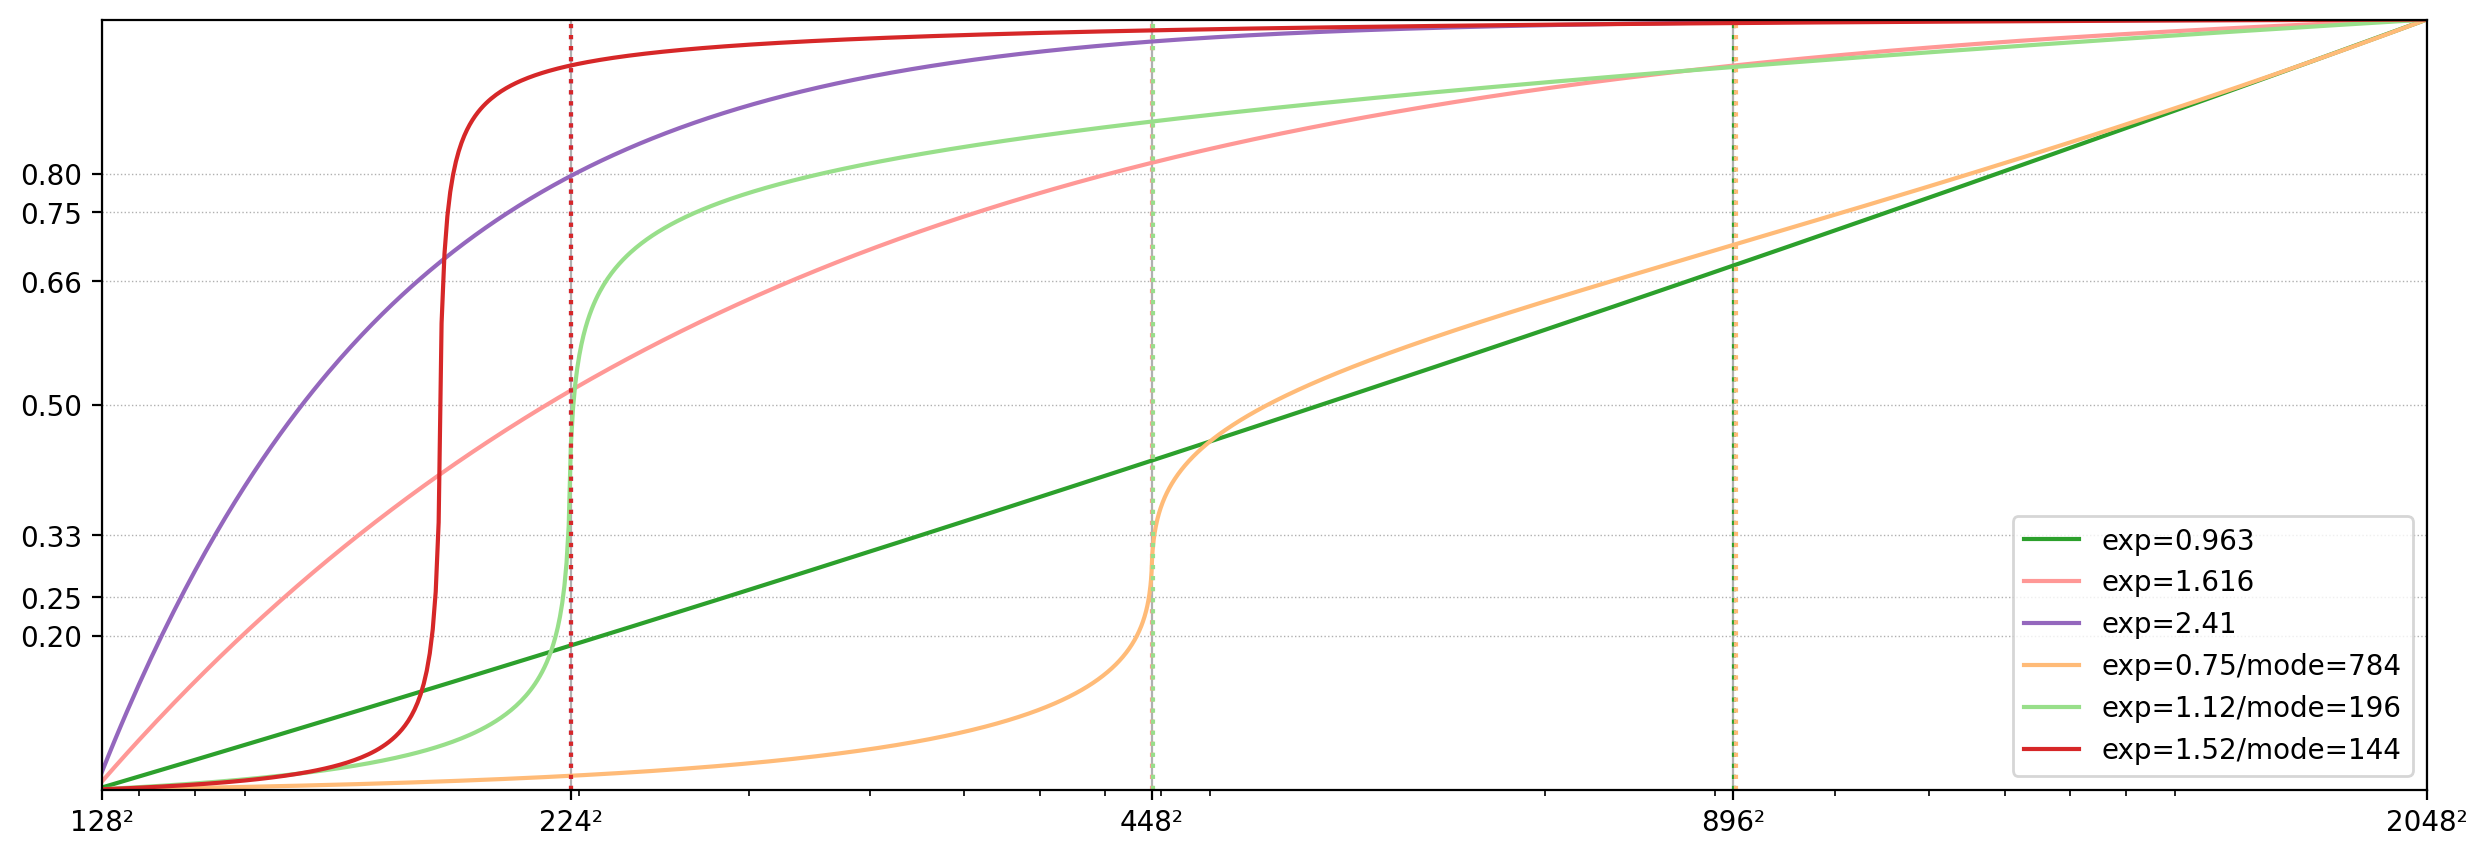

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
# for exp in [0.66, 1/1.25, 1, 1.25, 1.5, 1.6, 2.4]:
for exp, c in [
    (0.963, mpl.cm.tab20(4)),  # 896px²
    (1.616, mpl.cm.tab20(7)),  # 448px²
    (2.410, mpl.cm.tab20(8)),  # 224px²
]:
    p, v = _patch_vals(min_patches=64, max_patches=16_384, exp=exp, mode_patches=None)
    l, = ax.plot(v, np.cumsum(p), label=f'{exp=}', c=c);
    ax.vlines([np.sum(p * v) / np.sum(p)], 0, 1, colors=l.get_color(), ls=':')
for exp, mode, c in [
    (0.75, 784, mpl.cm.tab20(3)),  # 448 mode, 896 expectation
    (1.12, 196, mpl.cm.tab20(5)),  # 224 mode, 448 expectation
    (1.52, 144, mpl.cm.tab20(6)),  # 192 mode, 224 expectation
]:
    p, v = _patch_vals(min_patches=64, max_patches=16_384, exp=exp, mode_patches=mode)
    l, = ax.plot(v, np.cumsum(p), label=f'{exp=}/{mode=}', c=c);
    ax.vlines([np.sum(p * v) / np.sum(p)], 0, 1, colors=l.get_color(), ls=':')
ax.set_xscale('log');
ax.set_xlim(64, 16_384)
# ax.set_yscale('log');
ax.set_ylim(0.0, 1.0)
ax.set_xticks([64, 196, 784, 3136, 16_384], ['128²', '224²', '448²', '896²', '2048²']);
ax.legend();
ax.xaxis.grid(True, 'major')
ax.set_yticks([0.2, 0.25, 0.33, 0.5, 0.66, 0.75, 0.8])
ax.yaxis.grid(True, 'major', ls=':', lw=0.5)

The colors correspond to the run colors in this FlättliBrettli: http://localhost:1338/?share=cool-grep-lion